# 02 - Extended Preprocessing

Rozszerzony preprocessing zestawu CIC-DDoS2019 dla klasyfikacji binarnej (BENIGN vs DDoS).

**Kroki:**
1. Podstawowe czyszczenie danych (jak w `02_preprocessing.ipynb`)
2. **Normalizacja** - StandardScaler i MinMaxScaler
3. **Balansowanie klas** - SMOTE (oversampling) oraz RandomUnderSampler (undersampling)
4. **Feature Selection** - SelectKBest, VarianceThreshold
5. Zapisanie wielu wersji danych do dalszego modelowania

In [2]:
# Imports
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
# Configuration
DATA_DIR = "../data/raw/CSVs"
OUTPUT_DIR = "../data/processed"
SAMPLE_ROWS = 1000
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Krok 1: Wczytanie i podstawowe czyszczenie danych

Powtórzenie kroków z `02_preprocessing.ipynb`:
- Wczytanie próbek z plików CSV
- Czyszczenie nazw kolumn
- Usuwanie duplikatów
- Zamiana inf na NaN i usuwanie wierszy z NaN
- Kodowanie targetu (BENIGN=0, DDoS=1)
- Usunięcie kolumn identyfikacyjnych

In [4]:
# Znajdź pliki CSV
csv_files = glob.glob(f"{DATA_DIR}/**/*.csv", recursive=True)
print(f"Znaleziono {len(csv_files)} plików CSV")

# Załaduj dane
def load_and_sample(filepath, n_rows=SAMPLE_ROWS):
    return pd.read_csv(filepath, nrows=n_rows, low_memory=False)

dfs = []
for f in csv_files:
    df_part = load_and_sample(f)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
print(f"Łącznie: {len(df):,} wierszy, {df.shape[1]} kolumn")
df.head()

Znaleziono 18 plików CSV
Łącznie: 18,000 wierszy, 88 kolumn


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,0,172.16.0.5-192.168.50.1-60675-80-6,172.16.0.5,60675,192.168.50.1,80,6,2018-12-01 09:17:11.183810,5220876,12,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,205.174.165.72/c.php,1,DrDoS_NTP
1,7,172.16.0.5-192.168.50.1-60676-80-6,172.16.0.5,60676,192.168.50.1,80,6,2018-12-01 09:17:11.205636,12644252,5,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,DrDoS_NTP
2,12858,192.168.50.7-65.55.163.78-50458-443-6,65.55.163.78,443,192.168.50.7,50458,6,2018-12-01 09:17:12.634569,3,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,BENIGN
3,10191,192.168.50.7-65.55.163.78-50465-443-6,65.55.163.78,443,192.168.50.7,50465,6,2018-12-01 09:17:13.458370,3,2,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0,1,BENIGN
4,239,192.168.50.253-224.0.0.5-0-0-0,192.168.50.253,0,224.0.0.5,0,0,2018-12-01 09:17:13.470913,114329232,52,...,2.466441,15.0,6.0,9527428.0,248706.681286,9950741.0,9092248.0,0,0,BENIGN


In [5]:
# Wyczyść nazwy kolumn
df.columns = df.columns.str.strip()
print("Wyczyszczone nazwy kolumn")

Wyczyszczone nazwy kolumn


In [6]:
# Usuń duplikaty
rows_before = len(df)
df = df.drop_duplicates()
print(f"Usunięto {rows_before - len(df)} duplikatów")

Usunięto 0 duplikatów


In [7]:
# Zamiana inf na NaN
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print(f"Zamieniono wartości nieskończone na NaN")

Zamieniono wartości nieskończone na NaN


In [8]:
# Usuń wiersze z NaN
rows_before = len(df)
df = df.dropna()
print(f"Usunięto {rows_before - len(df)} wierszy z brakującymi wartościami")
print(f"Pozostało: {len(df):,} wierszy")

Usunięto 516 wierszy z brakującymi wartościami
Pozostało: 17,484 wierszy


In [9]:
# Kodowanie targetu
df["target"] = df["Label"].apply(lambda label: 0 if label == "BENIGN" else 1)
df = df.drop(columns=["Label"])

print("Rozkład targetu:")
print(df["target"].value_counts())
print(f"\nKlasa DDoS (1): {100 * df['target'].sum() / len(df):.2f}%")

Rozkład targetu:
target
1    15480
0     2004
Name: count, dtype: int64

Klasa DDoS (1): 88.54%


In [10]:
# Usuń kolumny identyfikacyjne
identifier_cols = [
    "Unnamed: 0",
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp",
    "SimillarHTTP"
]
existing_identifier_cols = [col for col in identifier_cols if col in df.columns]
df = df.drop(columns=existing_identifier_cols)

print(f"Usunięto kolumny: {existing_identifier_cols}")
print(f"Kształt po usunięciu: {df.shape}")

Usunięto kolumny: ['Unnamed: 0', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP']
Kształt po usunięciu: (17484, 82)


In [11]:
# Rozdziel cechy od targetu
X = df.drop(columns=["target"])
y = df["target"]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (17484, 81)
Target: (17484,)


## Krok 2: Normalizacja

Utworzenie dwóch wersji znormalizowanych danych:
- **StandardScaler** - standaryzacja (mean=0, std=1)
- **MinMaxScaler** - skalowanie do zakresu [0, 1]

In [12]:
# StandardScaler
scaler_standard = StandardScaler()
X_standard = pd.DataFrame(
    scaler_standard.fit_transform(X),
    columns=X.columns,
    index=X.index
)
print("StandardScaler zastosowany")
print(f"Średnia (pierwszych 3 kolumn): {X_standard.iloc[:, :3].mean().values}")

StandardScaler zastosowany
Średnia (pierwszych 3 kolumn): [0.00000000e+00 7.80280286e-17 1.17042043e-16]


In [13]:
# MinMaxScaler
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(X),
    columns=X.columns,
    index=X.index
)
print("MinMaxScaler zastosowany")
print(f"Min (pierwszych 3 kolumn): {X_minmax.iloc[:, :3].min().values}")
print(f"Max (pierwszych 3 kolumn): {X_minmax.iloc[:, :3].max().values}")

MinMaxScaler zastosowany
Min (pierwszych 3 kolumn): [0. 0. 0.]
Max (pierwszych 3 kolumn): [1. 1. 1.]


## Krok 3: Balansowanie klas

Zastosowanie technik balansowania:
- **SMOTE** - Synthetic Minority Over-sampling Technique (nadpróbkowanie klasy mniejszościowej)
- **RandomUnderSampler** - losowe podpróbkowanie klasy większościowej

Balansowanie zostanie zastosowane na danych znormalizowanych (StandardScaler).

In [14]:
# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_standard, y)

print("SMOTE zastosowany")
print(f"Przed: {y.value_counts().to_dict()}")
print(f"Po: {pd.Series(y_smote).value_counts().to_dict()}")

SMOTE zastosowany
Przed: {1: 15480, 0: 2004}
Po: {1: 15480, 0: 15480}


In [15]:
# RandomUnderSampler
undersampler = RandomUnderSampler(random_state=RANDOM_STATE)
X_under, y_under = undersampler.fit_resample(X_standard, y)

print("RandomUnderSampler zastosowany")
print(f"Przed: {y.value_counts().to_dict()}")
print(f"Po: {pd.Series(y_under).value_counts().to_dict()}")

RandomUnderSampler zastosowany
Przed: {1: 15480, 0: 2004}
Po: {0: 2004, 1: 2004}


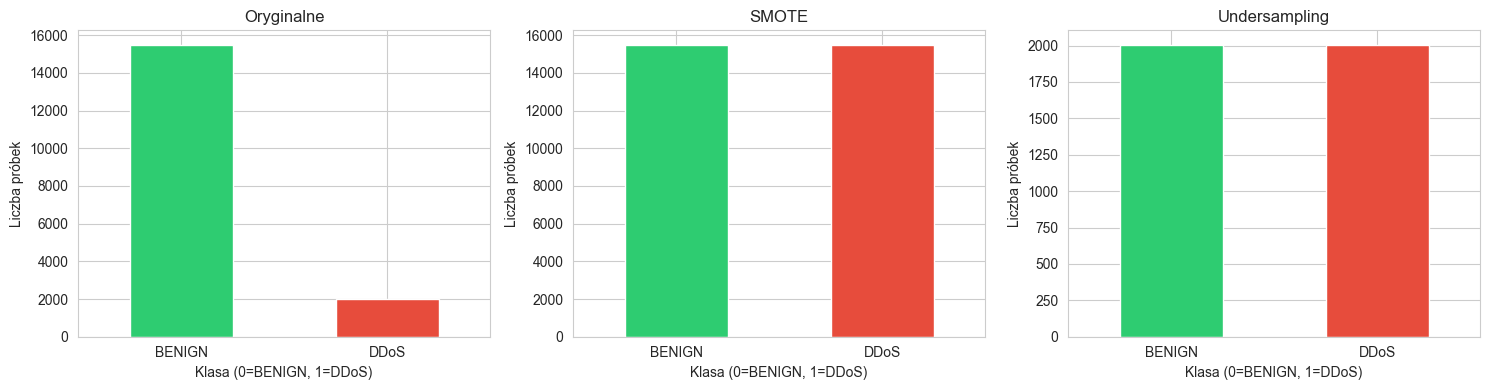

In [16]:
# Wizualizacja rozkładu klas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, target) in zip(axes, [
    ("Oryginalne", y),
    ("SMOTE", pd.Series(y_smote)),
    ("Undersampling", pd.Series(y_under))
]):
    target.value_counts().plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"])
    ax.set_title(title)
    ax.set_xlabel("Klasa (0=BENIGN, 1=DDoS)")
    ax.set_ylabel("Liczba próbek")
    ax.set_xticklabels(["BENIGN", "DDoS"], rotation=0)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_balance_comparison.png", dpi=150)
plt.show()

## Krok 4: Feature Selection

Zastosowanie technik selekcji cech:
1. **VarianceThreshold** - usunięcie cech o niskiej wariancji
2. **SelectKBest** - wybór k najlepszych cech według testu ANOVA F-value

In [17]:
# VarianceThreshold - usuń cechy o wariancji < 0.01
selector_var = VarianceThreshold(threshold=0.01)
X_var = pd.DataFrame(
    selector_var.fit_transform(X_standard),
    columns=X_standard.columns[selector_var.get_support()],
    index=X_standard.index
)

print(f"VarianceThreshold zastosowany")
print(f"Usunięto {X_standard.shape[1] - X_var.shape[1]} cech o niskiej wariancji")
print(f"Pozostało: {X_var.shape[1]} cech")

VarianceThreshold zastosowany
Usunięto 12 cech o niskiej wariancji
Pozostało: 69 cech


In [18]:
# SelectKBest - wybierz 30 najlepszych cech
k = 30
selector_kbest = SelectKBest(score_func=f_classif, k=k)
X_kbest = pd.DataFrame(
    selector_kbest.fit_transform(X_standard, y),
    columns=X_standard.columns[selector_kbest.get_support()],
    index=X_standard.index
)

print(f"SelectKBest zastosowany (k={k})")
print(f"Wybrane cechy:")
print(X_kbest.columns.tolist())

SelectKBest zastosowany (k=30)
Wybrane cechy:
['Source Port', 'Destination Port', 'Protocol', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Bwd IAT Total', 'Fwd PSH Flags', 'Bwd Header Length', 'Fwd Packets/s', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Init_Win_bytes_backward', 'Inbound']


/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [33 34 35 45 48 52 58 59 60 61 62 63] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


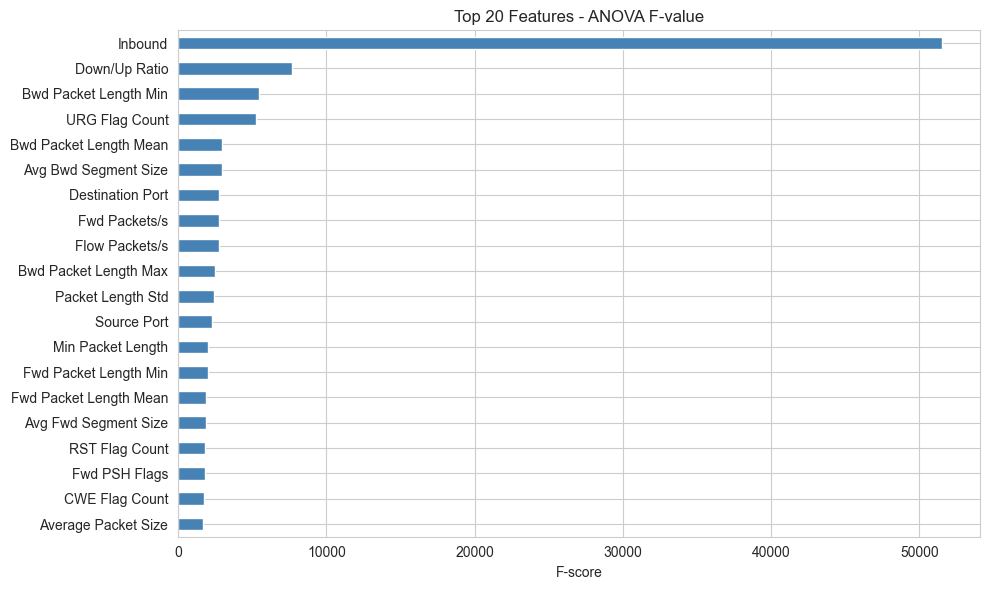

In [19]:
# Wizualizacja top 20 cech według F-score
scores = pd.Series(selector_kbest.scores_, index=X_standard.columns)
top20 = scores.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Features - ANOVA F-value")
ax.set_xlabel("F-score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_selection_scores.png", dpi=150)
plt.show()

## Krok 5: Zapis przetworzonych danych

Zapisanie wielu wersji danych dla różnych scenariuszy:
1. `ddos_standard_scaled.csv` - StandardScaler, bez balansowania
2. `ddos_minmax_scaled.csv` - MinMaxScaler, bez balansowania
3. `ddos_smote.csv` - SMOTE + StandardScaler
4. `ddos_undersampled.csv` - Undersampling + StandardScaler
5. `ddos_variance_threshold.csv` - VarianceThreshold + StandardScaler
6. `ddos_kbest_30.csv` - SelectKBest (30 cech) + StandardScaler

In [20]:
# Zapisz wszystkie wersje
versions = [
    ("ddos_standard_scaled.csv", X_standard, y),
    ("ddos_minmax_scaled.csv", X_minmax, y),
    ("ddos_smote.csv", pd.DataFrame(X_smote, columns=X_standard.columns), pd.Series(y_smote)),
    ("ddos_undersampled.csv", pd.DataFrame(X_under, columns=X_standard.columns), pd.Series(y_under)),
    ("ddos_variance_threshold.csv", X_var, y),
    ("ddos_kbest_30.csv", X_kbest, y),
]

for filename, features, target in versions:
    output_path = os.path.join(OUTPUT_DIR, filename)
    combined = features.copy()
    combined["target"] = target.values
    combined.to_csv(output_path, index=False)
    print(f"Zapisano: {output_path} ({len(combined)} wierszy, {len(combined.columns)} kolumn)")

Zapisano: ../data/processed/ddos_standard_scaled.csv (17484 wierszy, 82 kolumn)
Zapisano: ../data/processed/ddos_minmax_scaled.csv (17484 wierszy, 82 kolumn)
Zapisano: ../data/processed/ddos_smote.csv (30960 wierszy, 82 kolumn)
Zapisano: ../data/processed/ddos_undersampled.csv (4008 wierszy, 82 kolumn)
Zapisano: ../data/processed/ddos_variance_threshold.csv (17484 wierszy, 70 kolumn)
Zapisano: ../data/processed/ddos_kbest_30.csv (17484 wierszy, 31 kolumn)


## Podsumowanie

Utworzono 6 wersji przetworzonych danych:
1. **StandardScaler** - standaryzacja
2. **MinMaxScaler** - skalowanie 0-1
3. **SMOTE** - oversampling klasy mniejszościowej
4. **Undersampling** - losowe zmniejszenie klasy większościowej
5. **VarianceThreshold** - usunięcie cech o niskiej wariancji
6. **SelectKBest** - wybór 30 najlepszych cech

Wszystkie pliki są gotowe do użycia w notebooku `03_modeling.ipynb`.